# Визуализация единой multiclass photoswitch-модели

Notebook читает свежий balanced top-1000 из
`generated_multiclass_photoswitch.csv`, полученный одним conditional
SELFIES-GRU с family-токенами `<AZO>`, `<STILBENE>`, `<SPIROPYRAN>` и
`<DIARYLETHENE>`.

В выборке четыре сбалансированных класса: azo, stilbene, spiropyran и
diarylethene. Два последних имеют reaction-constrained open/closed pairs.
Второе химическое пространство — экспериментально обученный phototoxicity
screen; ADME-like величины используются только как признаки модели.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from rdkit import Chem, RDLogger
from rdkit.Chem import Draw

RDLogger.DisableLog("rdApp.*")
ROOT = Path.cwd().resolve()
CSV_PATH = ROOT / "generated_multiclass_photoswitch.csv"
METRICS_PATH = ROOT / "outputs" / "uv_most_multiclass" / "generation_metrics.csv"
TOXICITY_METRICS_PATH = ROOT / "outputs" / "uv_most_multiclass" / "phototoxicity_model_metrics.csv"
TOXICITY_TRAINING_PATH = ROOT / "outputs" / "uv_most_multiclass" / "phototoxicity_training.csv"
df = pd.read_csv(CSV_PATH)
required = {
    "selection_rank", "candidate_id", "rank_within_family", "family",
    "canonical_smiles", "state_A_smiles", "state_B_smiles",
    "pair_valid", "eval_uv_lambda_nm", "eval_uv_uncertainty_nm", "sa_score",
    "reward", "selection_score", "target_A_pass", "target_B_pass",
    "photoswitch_space_pass", "toxicity_space_pass", "phototoxic_probability",
    "phototoxic_uncertainty", "phototoxic_upper_confidence", "toxicity_similarity",
    "toxicity_in_domain", "toxicity_pass",
    "joint_success", "PSS_pred", "quantum_yield_pred", "deltaH_kJ_mol",
    "stored_energy_MJ_kg", "final_status",
}
missing = required.difference(df.columns)
if missing:
    raise KeyError(f"generated_multiclass_photoswitch.csv is missing: {sorted(missing)}")
if len(df) != 1000 or df["canonical_smiles"].nunique() != 1000:
    raise ValueError("Expected exactly 1000 globally unique fresh candidates")
print(f"Loaded {len(df):,} rows from {CSV_PATH}")
print("Families:", df["family"].value_counts().to_dict())
print("Unique structures:", df.groupby("family")["canonical_smiles"].nunique().to_dict())
print("Selection ranks:", (int(df["selection_rank"].min()), int(df["selection_rank"].max())))

Loaded 1,000 rows from /home/sigmatau17/TEST/generated_multiclass_photoswitch.csv
Families: {'azo': 250, 'stilbene': 250, 'spiropyran': 250, 'diarylethene': 250}
Unique structures: {'azo': 250, 'diarylethene': 250, 'spiropyran': 250, 'stilbene': 250}
Selection ranks: (1, 1000)


## Состав свежего top-1000 и ранжирование

,family,rows,unique,proxy_pass,median_uv_nm,median_uv_uncertainty_nm,median_sa,median_phototoxic_probability,toxicity_in_domain_rate,median_selection_score
0,azo,250,250,250,378.016685,59.778436,2.889533,0.471383,0.988,0.357383
1,diarylethene,250,250,244,379.928406,59.778436,3.376044,0.561347,0.384,0.383486
2,spiropyran,250,250,187,394.602039,59.778436,3.557138,0.606927,0.984,0.332096
3,stilbene,250,250,250,365.275908,59.778436,2.292802,0.299669,1.000,0.519208


final_status,FAIL_PHOTOSWITCH_OR_TOXICITY_SCREEN,PASS_AZO_AND_TOXICITY_SCREEN,PASS_DIARYLETHENE_AND_TOXICITY_SCREEN,PASS_SPIROPYRAN_AND_TOXICITY_SCREEN,PASS_STILBENE_AND_TOXICITY_SCREEN
family,,,,,
azo,0,250,0,0,0
diarylethene,6,0,244,0,0
spiropyran,63,0,0,187,0
stilbene,0,0,0,0,250


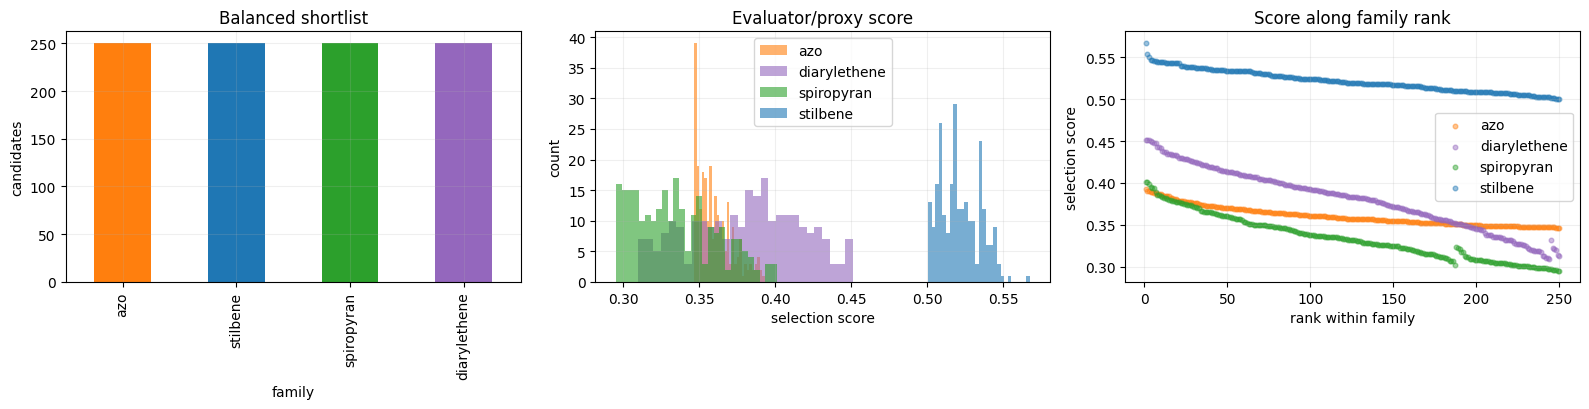

In [2]:
summary = (
    df.groupby("family", as_index=False)
      .agg(
          rows=("canonical_smiles", "size"),
          unique=("canonical_smiles", "nunique"),
          proxy_pass=("final_status", lambda x: int(x.str.startswith("PASS").sum())),
          median_uv_nm=("eval_uv_lambda_nm", "median"),
          median_uv_uncertainty_nm=("eval_uv_uncertainty_nm", "median"),
          median_sa=("sa_score", "median"),
          median_phototoxic_probability=("phototoxic_probability", "median"),
          toxicity_in_domain_rate=("toxicity_in_domain", "mean"),
          median_selection_score=("selection_score", "median"),
      )
)
display(summary)
display(pd.crosstab(df["family"], df["final_status"]))

family_order = ["azo", "stilbene", "spiropyran", "diarylethene"]
colors = {"azo":"tab:orange", "stilbene":"tab:blue", "spiropyran":"tab:green", "diarylethene":"tab:purple"}
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
df["family"].value_counts().reindex(family_order).plot.bar(
    ax=axes[0], color=[colors[family] for family in family_order]
)
axes[0].set(title="Balanced shortlist", xlabel="family", ylabel="candidates")
for family, part in df.groupby("family"):
    axes[1].hist(part["selection_score"], bins=28, alpha=0.6, color=colors[family], label=family)
    axes[2].scatter(
        part["rank_within_family"], part["selection_score"],
        s=11, alpha=0.45, color=colors[family], label=family,
    )
axes[1].set(title="Evaluator/proxy score", xlabel="selection score", ylabel="count")
axes[2].set(title="Score along family rank", xlabel="rank within family", ylabel="selection score")
for axis in axes[1:]:
    axis.legend()
for axis in axes:
    axis.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## Общий UV proxy и synthetic accessibility

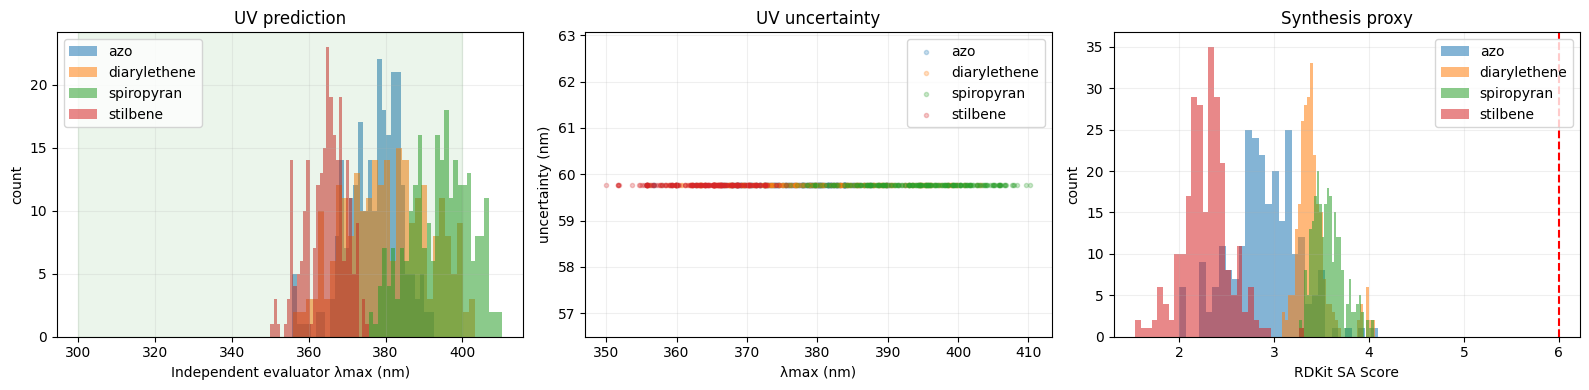

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for family, part in df.groupby("family"):
    axes[0].hist(part["eval_uv_lambda_nm"], bins=30, alpha=0.55, label=family)
    axes[1].scatter(part["eval_uv_lambda_nm"], part["eval_uv_uncertainty_nm"], s=9, alpha=0.25, label=family)
    axes[2].hist(part["sa_score"], bins=30, alpha=0.55, label=family)
axes[0].axvspan(300, 400, color="green", alpha=0.08)
axes[0].set(xlabel="Independent evaluator λmax (nm)", ylabel="count", title="UV prediction")
axes[1].set(xlabel="λmax (nm)", ylabel="uncertainty (nm)", title="UV uncertainty")
axes[2].axvline(6.0, color="red", ls="--")
axes[2].set(xlabel="RDKit SA Score", ylabel="count", title="Synthesis proxy")
for axis in axes:
    axis.legend()
    axis.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## Azo-specific spectral separation и half-life

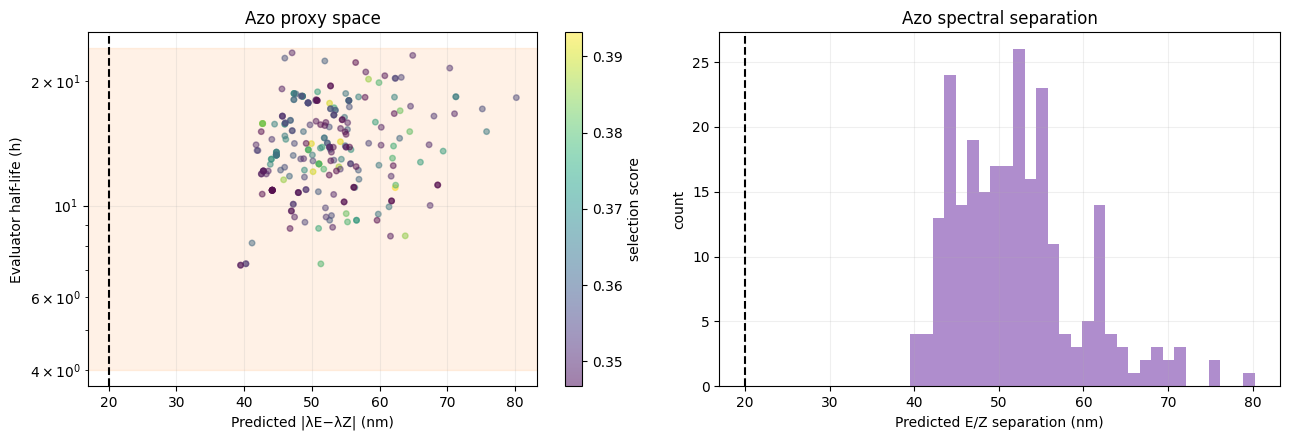

In [4]:
azo = df[df["family"].eq("azo")].dropna(subset=["pred_delta_lambda_nm", "eval_half_life_h"])
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
scatter = axes[0].scatter(
    azo["pred_delta_lambda_nm"], azo["eval_half_life_h"],
    c=azo["selection_score"], cmap="viridis", s=16, alpha=0.5,
)
axes[0].axvline(20, color="black", ls="--")
axes[0].axhspan(4, 24, color="tab:orange", alpha=0.1)
axes[0].set_yscale("log")
axes[0].set(xlabel="Predicted |λE−λZ| (nm)", ylabel="Evaluator half-life (h)", title="Azo proxy space")
fig.colorbar(scatter, ax=axes[0], label="selection score")
axes[1].hist(azo["pred_delta_lambda_nm"], bins=30, color="tab:purple", alpha=0.75)
axes[1].axvline(20, color="black", ls="--")
axes[1].set(xlabel="Predicted E/Z separation (nm)", ylabel="count", title="Azo spectral separation")
for axis in axes:
    axis.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## Экспериментально обученный phototoxicity screen

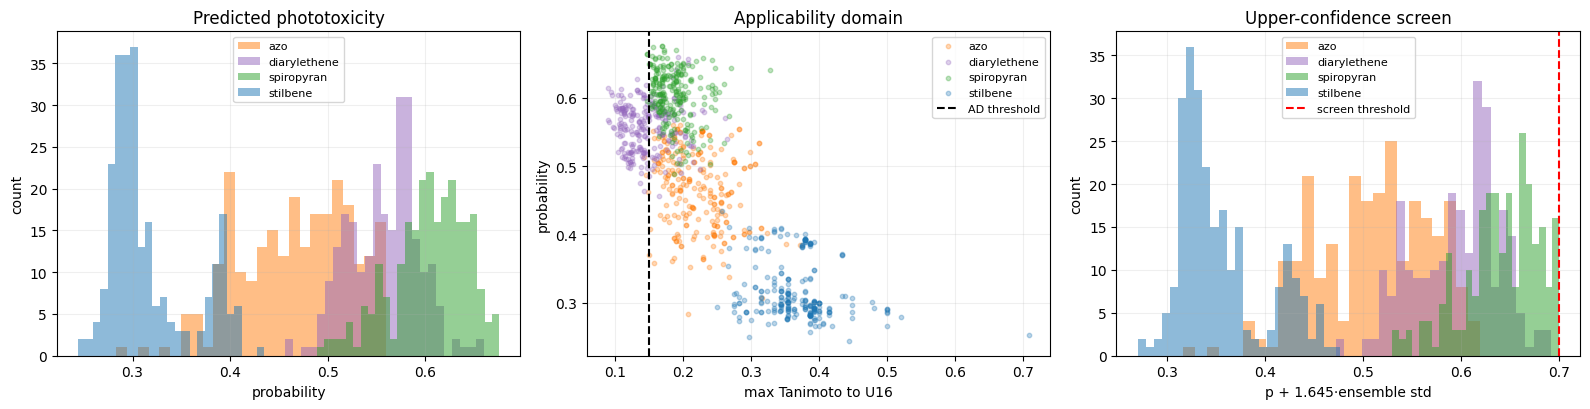

,screen_pass_rate,in_domain_rate,median_probability,median_upper_confidence
family,,,,
azo,1.0,0.988,0.471383,0.515021
diarylethene,1.0,0.384,0.561347,0.602286
spiropyran,1.0,0.984,0.606927,0.645063
stilbene,1.0,1.000,0.299669,0.338535


toxicity_risk_band,low_model_risk,uncertain,screened_out_high_risk
family,,,
azo,2,248,0
diarylethene,0,250,0
spiropyran,0,250,0
stilbene,147,103,0


Важно: screen_pass — критерий приоритизации, а не экспериментальное доказательство безопасности.


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
df["toxicity_risk_band"] = pd.cut(
    df["phototoxic_upper_confidence"], bins=[-np.inf,.35,.70,np.inf],
    labels=["low_model_risk", "uncertain", "screened_out_high_risk"], right=False,
)
for family, part in df.groupby("family"):
    axes[0].hist(part["phototoxic_probability"], bins=25, alpha=.5, color=colors[family], label=family)
    axes[1].scatter(part["toxicity_similarity"], part["phototoxic_probability"], s=10, alpha=.3,
                    color=colors[family], label=family)
    axes[2].hist(part["phototoxic_upper_confidence"], bins=25, alpha=.5, color=colors[family], label=family)
axes[0].set(title="Predicted phototoxicity", xlabel="probability", ylabel="count")
axes[1].axvline(.15, color="black", ls="--", label="AD threshold")
axes[1].set(title="Applicability domain", xlabel="max Tanimoto to U16", ylabel="probability")
axes[2].axvline(.70, color="red", ls="--", label="screen threshold")
axes[2].set(title="Upper-confidence screen", xlabel="p + 1.645·ensemble std", ylabel="count")
for axis in axes:
    axis.grid(alpha=.2); axis.legend(fontsize=8)
plt.tight_layout(); plt.show()

display(df.groupby("family").agg(
    screen_pass_rate=("toxicity_pass","mean"),
    in_domain_rate=("toxicity_in_domain","mean"),
    median_probability=("phototoxic_probability","median"),
    median_upper_confidence=("phototoxic_upper_confidence","median"),
))
display(pd.crosstab(df["family"], df["toxicity_risk_band"], dropna=False))
print("Важно: screen_pass — критерий приоритизации, а не экспериментальное доказательство безопасности.")

## Лучшие пары состояний каждого класса

,candidate_id,rank_within_family,canonical_smiles,state_A_smiles,state_B_smiles,eval_uv_lambda_nm,sa_score,selection_score,final_status
0,MC-AZO-0001,1,Cc1ccccc1N/N=N/C=Cc1cccc(N)c1,Cc1ccccc1N/N=N/C=Cc1cccc(N)c1,Cc1ccccc1N/N=N\C=Cc1cccc(N)c1,360.094126,2.713684,0.393140,PASS_AZO_AND_TOXICITY_SCREEN
1,MC-AZO-0002,2,CC=Cc1ccccc1N/N=N/C=Cc1cccc(O)c1,CC=Cc1ccccc1N/N=N/C=Cc1cccc(O)c1,CC=Cc1ccccc1N/N=N\C=Cc1cccc(O)c1,362.556322,3.008008,0.390902,PASS_AZO_AND_TOXICITY_SCREEN
2,MC-AZO-0003,3,Oc1ccc(O/N=N/C=Cc2cccc(Br)c2)nc1,Oc1ccc(O/N=N/C=Cc2cccc(Br)c2)nc1,Oc1ccc(O/N=N\C=Cc2cccc(Br)c2)nc1,356.619356,3.164640,0.390817,PASS_AZO_AND_TOXICITY_SCREEN
3,MC-AZO-0004,4,Oc1ccc(/N=N/N=N\c2ccccc2C=Nc2ccccc2)cc1,Oc1ccc(/N=N/N=N\c2ccccc2C=Nc2ccccc2)cc1,Oc1ccc(/N=N\N=N/c2ccccc2C=Nc2ccccc2)cc1,359.211592,2.925366,0.389647,PASS_AZO_AND_TOXICITY_SCREEN
4,MC-AZO-0005,5,C/N=N/Nc1ccccc1C,C/N=N/Nc1ccccc1C,C/N=N\Nc1ccccc1C,356.829032,2.405626,0.389588,PASS_AZO_AND_TOXICITY_SCREEN
5,MC-AZO-0006,6,Oc1ccc(Br)cc1C=C/N=N/N=N/c1ccccc1,Oc1ccc(Br)cc1C=C/N=N/N=N/c1ccccc1,Oc1ccc(Br)cc1C=C/N=N\N=N\c1ccccc1,366.769395,3.127321,0.388215,PASS_AZO_AND_TOXICITY_SCREEN
6,MC-AZO-0007,7,Oc1ccc(Br)cc1C=C/N=N\N=N\c1ccccc1,Oc1ccc(Br)cc1C=C/N=N/N=N/c1ccccc1,Oc1ccc(Br)cc1C=C/N=N\N=N\c1ccccc1,366.769395,3.127321,0.388215,PASS_AZO_AND_TOXICITY_SCREEN
7,MC-AZO-0008,8,Brc1cccc(C=C/N=N/N=N/c2ccccc2)c1,Brc1cccc(C=C/N=N/N=N/c2ccccc2)c1,Brc1cccc(C=C/N=N\N=N\c2ccccc2)c1,366.956488,2.980775,0.386798,PASS_AZO_AND_TOXICITY_SCREEN
8,MC-AZO-0009,9,Brc1cccc(C=C/N=N\N=N\c2ccccc2)c1,Brc1cccc(C=C/N=N/N=N/c2ccccc2)c1,Brc1cccc(C=C/N=N\N=N\c2ccccc2)c1,366.956488,2.980775,0.386798,PASS_AZO_AND_TOXICITY_SCREEN


azo: state A


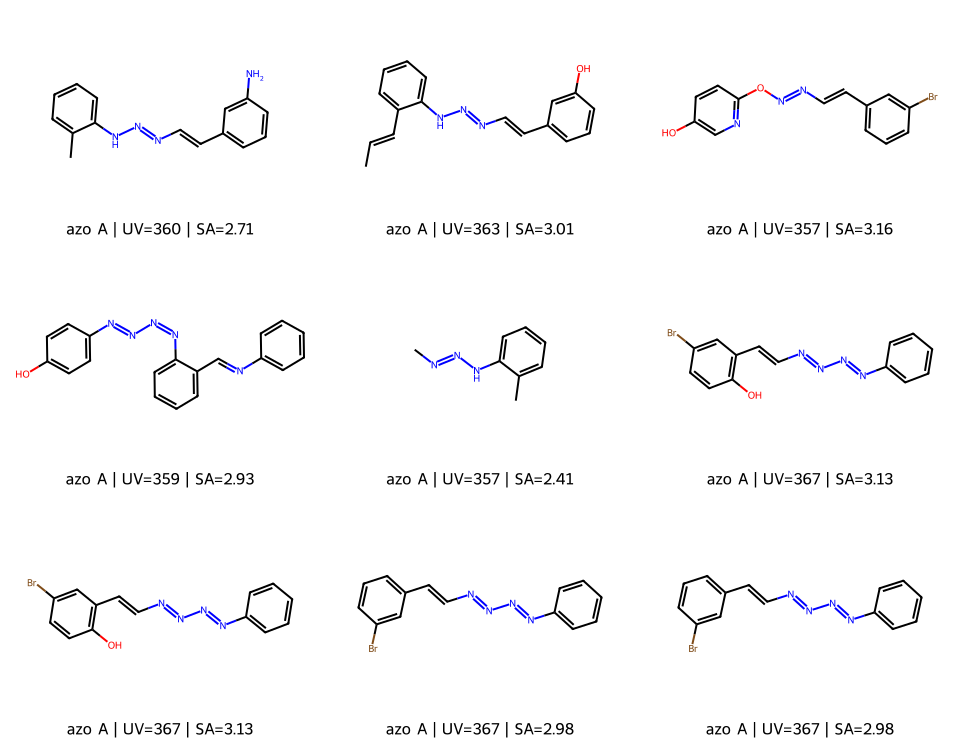

azo: corresponding state B


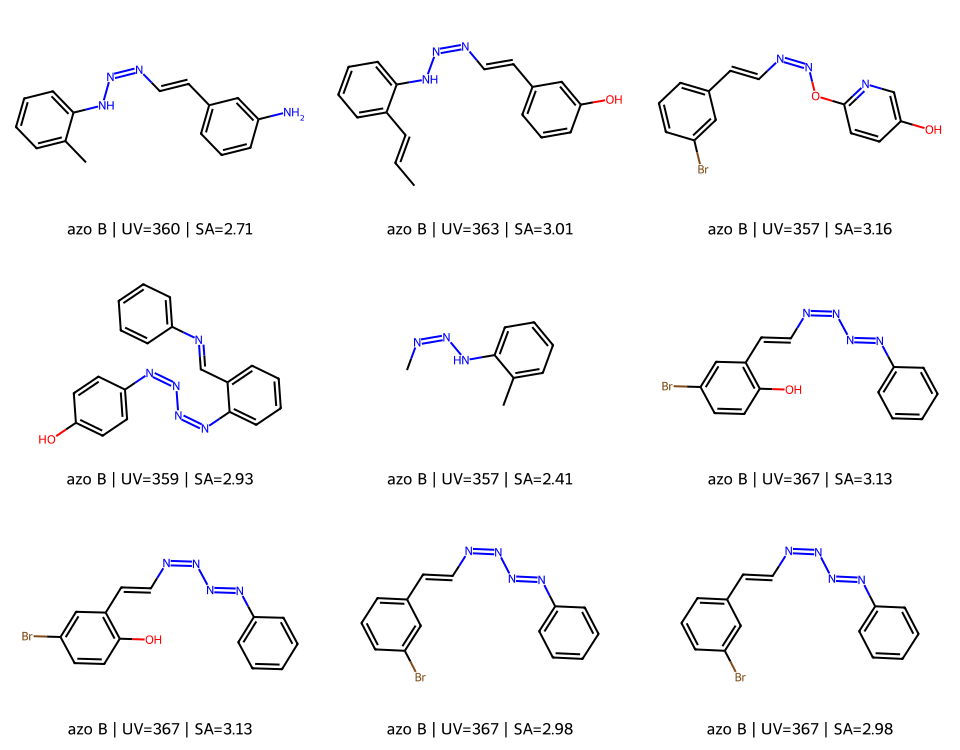

,candidate_id,rank_within_family,canonical_smiles,state_A_smiles,state_B_smiles,eval_uv_lambda_nm,sa_score,selection_score,final_status
250,MC-STILBENE-0251,1,C(=Cc1ccccn1)c1ccccc1,C(=C\c1ccccn1)/c1ccccc1,C(=C/c1ccccn1)/c1ccccc1,350.034670,1.744879,0.567483,PASS_STILBENE_AND_TOXICITY_SCREEN
251,MC-STILBENE-0252,2,C(=Cc1ccccc1C=Cc1ccccc1C=Cc1ccccc1)c1ccccc1,C(=Cc1ccccc1C=Cc1ccccc1/C=C/c1ccccc1)c1ccccc1,C(=Cc1ccccc1C=Cc1ccccc1/C=C\c1ccccc1)c1ccccc1,357.319035,1.788283,0.554486,PASS_STILBENE_AND_TOXICITY_SCREEN
252,MC-STILBENE-0253,3,C(=Cc1ccccc1C=Cc1ccccccccn1)c1ccccc1,C(=Cc1ccccc1/C=C/c1ccccc1)c1ccccccccn1,C(=Cc1ccccc1/C=C\c1ccccc1)c1ccccccccn1,358.319505,2.470125,0.550663,PASS_STILBENE_AND_TOXICITY_SCREEN
253,MC-STILBENE-0254,4,Nc1ccccc1C=Cc1ccccc1C=Cc1ccccc1C=Cc1ccccc1,Nc1ccccc1/C=C/c1ccccc1C=Cc1ccccc1C=Cc1ccccc1,Nc1ccccc1/C=C\c1ccccc1C=Cc1ccccc1C=Cc1ccccc1,356.637500,2.168839,0.546703,PASS_STILBENE_AND_TOXICITY_SCREEN
254,MC-STILBENE-0255,5,Nc1ccccc1C=Cc1ccccc1C=Cc1ccccc1,Nc1ccccc1/C=C/c1ccccc1C=Cc1ccccc1,Nc1ccccc1/C=C\c1ccccc1C=Cc1ccccc1,356.637500,2.067350,0.546533,PASS_STILBENE_AND_TOXICITY_SCREEN
255,MC-STILBENE-0256,6,C(=Cc1ccccc1C=Cc1ccccc1/C=C/c1ccncc1)c1ccccc1,C(=Cc1ccccc1/C=C/c1ccncc1)c1ccccc1/C=C/c1ccccc1,C(=Cc1ccccc1/C=C/c1ccncc1)c1ccccc1/C=C\c1ccccc1,355.364981,2.167891,0.546127,PASS_STILBENE_AND_TOXICITY_SCREEN
256,MC-STILBENE-0257,7,COc1ccccc1C=Cc1ccccc1,COc1ccccc1/C=C/c1ccccc1,COc1ccccc1/C=C\c1ccccc1,359.900693,1.533901,0.545688,PASS_STILBENE_AND_TOXICITY_SCREEN
257,MC-STILBENE-0258,8,COc1ccccc1C=Cc1ccccc1/C=C/c1ccccc1C=Cc1ccccc1C...,COc1ccccc1/C=C/c1ccccc1/C=C/c1ccccc1C=Cc1ccccc...,COc1ccccc1/C=C\c1ccccc1/C=C/c1ccccc1C=Cc1ccccc...,359.900693,2.311997,0.544233,PASS_STILBENE_AND_TOXICITY_SCREEN
258,MC-STILBENE-0259,9,COc1ccccc1C=Cc1ccccc1C=Cc1ccccc1C=Cc1ccccc1C=C...,COc1ccccc1/C=C/c1ccccc1C=Cc1ccccc1C=Cc1ccccc1C...,COc1ccccc1/C=C\c1ccccc1C=Cc1ccccc1C=Cc1ccccc1C...,359.900693,2.311997,0.544233,PASS_STILBENE_AND_TOXICITY_SCREEN


stilbene: state A


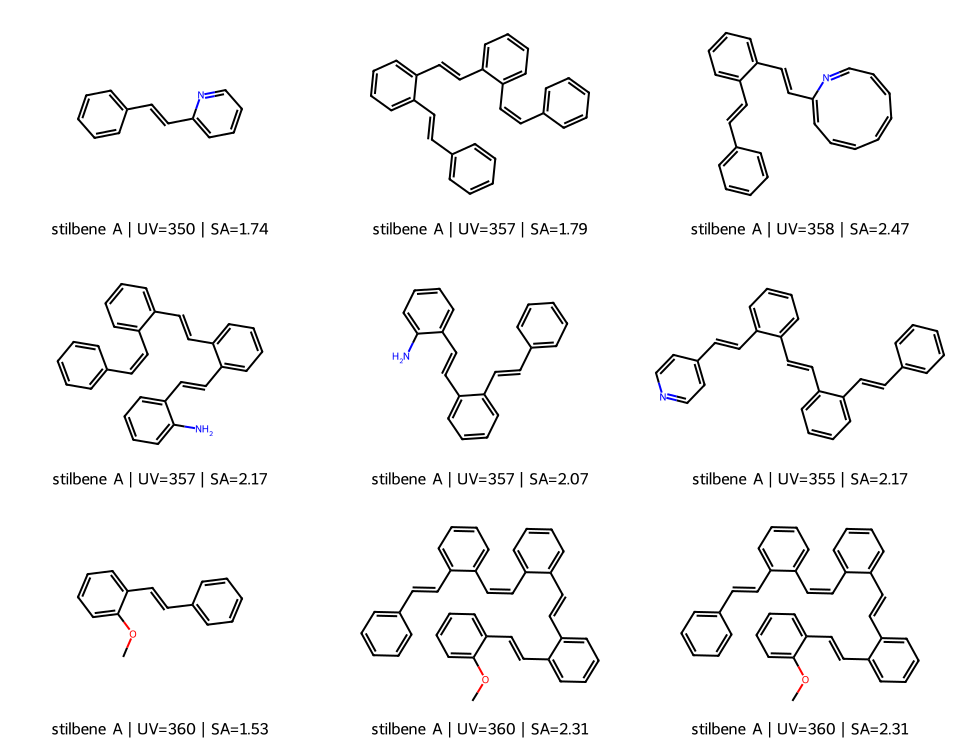

stilbene: corresponding state B


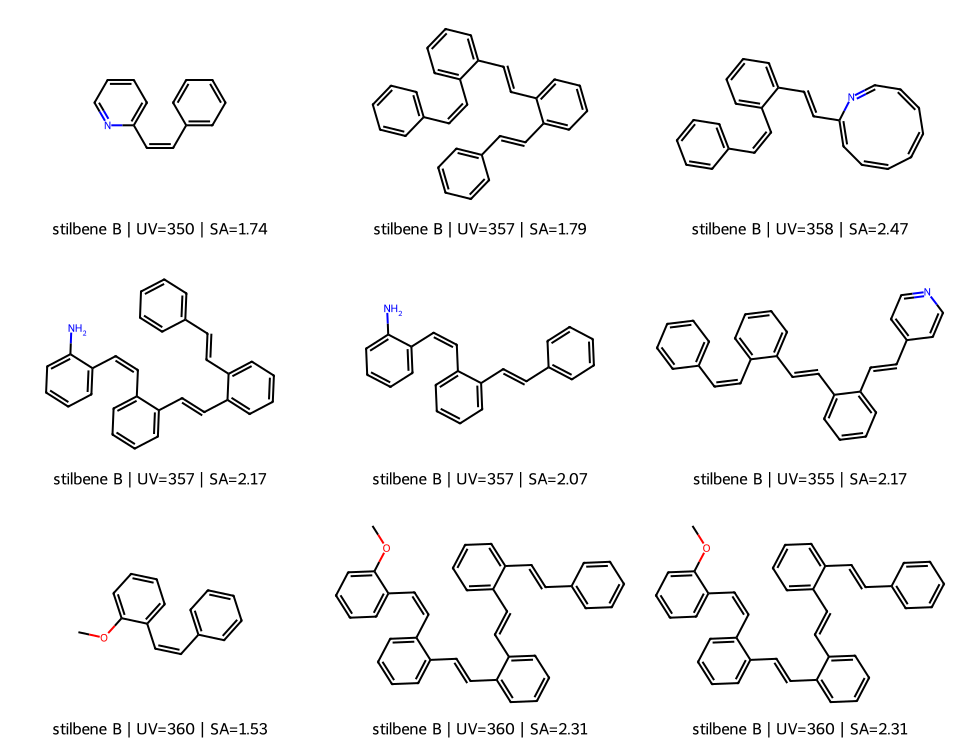

,candidate_id,rank_within_family,canonical_smiles,state_A_smiles,state_B_smiles,eval_uv_lambda_nm,sa_score,selection_score,final_status
500,MC-SPIROPYRAN-0501,1,COc1ccc(-c2cc(-c3ccccn3)cc3c2OC2(CCN(C)C2)C3)cc1,COc1ccc(-c2cc(-c3ccccn3)cc3c2OC2(CCN(C)C2)C3)cc1,COc1ccc(-c2cc(-c3ccccn3)cc(O)c2C=C2CCN(C)C2)cc1,377.158008,3.432832,0.401187,PASS_SPIROPYRAN_AND_TOXICITY_SCREEN
501,MC-SPIROPYRAN-0502,2,COc1cc(-c2ccccn2)cc2c1OC1(CCN(C)C1)C2,COc1cc(-c2ccccn2)cc2c1OC1(CCN(C)C1)C2,COc1cc(-c2ccccn2)cc(O)c1C=C1CCN(C)C1,379.629768,3.463612,0.400871,PASS_SPIROPYRAN_AND_TOXICITY_SCREEN
502,MC-SPIROPYRAN-0503,3,COc1cc(-c2ccccc2)cc2c1OC1(CCN(C)C1)C2,COc1cc(-c2ccccc2)cc2c1OC1(CCN(C)C1)C2,COc1cc(-c2ccccc2)cc(O)c1C=C1CCN(C)C1,378.576753,3.265610,0.399263,PASS_SPIROPYRAN_AND_TOXICITY_SCREEN
503,MC-SPIROPYRAN-0504,4,COc1cc(-c2ccncc2)cc2c1OC1(CCN(C)C1)C2,COc1cc(-c2ccncc2)cc2c1OC1(CCN(C)C1)C2,COc1cc(-c2ccncc2)cc(O)c1C=C1CCN(C)C1,376.051232,3.474347,0.394982,PASS_SPIROPYRAN_AND_TOXICITY_SCREEN
504,MC-SPIROPYRAN-0505,5,CN1CCC2(Cc3cc(-c4ccccc4)cc(O)c3O2)C1,CN1CCC2(Cc3cc(-c4ccccc4)cc(O)c3O2)C1,CN1CCC(=Cc2c(O)cc(-c3ccccc3)cc2O)C1,379.229332,3.433404,0.394089,PASS_SPIROPYRAN_AND_TOXICITY_SCREEN
505,MC-SPIROPYRAN-0506,6,COc1ccc(-c2cc(O)c3c(c2)CC2(CCN(C)C2)O3)cc1,COc1ccc(-c2cc(O)c3c(c2)CC2(CCN(C)C2)O3)cc1,COc1ccc(-c2cc(O)c(C=C3CCN(C)C3)c(O)c2)cc1,379.663433,3.438126,0.393780,PASS_SPIROPYRAN_AND_TOXICITY_SCREEN
506,MC-SPIROPYRAN-0507,7,CN1CCC2(Cc3cc(-c4ccncc4)cc(O)c3O2)C1,CN1CCC2(Cc3cc(-c4ccncc4)cc(O)c3O2)C1,CN1CCC(=Cc2c(O)cc(-c3ccncc3)cc2O)C1,378.708423,3.652407,0.389760,PASS_SPIROPYRAN_AND_TOXICITY_SCREEN
507,MC-SPIROPYRAN-0508,8,COc1ccc(-c2cc3c(c(-c4ccc(OC)cc4)c2)OC2(CCN(C)C...,COc1ccc(-c2cc3c(c(-c4ccc(OC)cc4)c2)OC2(CCN(C)C...,COc1ccc(-c2cc(O)c(C=C3CCN(C)C3)c(-c3ccc(OC)cc3...,377.934611,3.320304,0.386113,PASS_SPIROPYRAN_AND_TOXICITY_SCREEN
508,MC-SPIROPYRAN-0509,9,COc1ccc(-c2cc(-c3ccncc3)cc3c2OC2(CCN(C)C2)C3)cc1,COc1ccc(-c2cc(-c3ccncc3)cc3c2OC2(CCN(C)C2)C3)cc1,COc1ccc(-c2cc(-c3ccncc3)cc(O)c2C=C2CCN(C)C2)cc1,375.614376,3.441210,0.385887,PASS_SPIROPYRAN_AND_TOXICITY_SCREEN


spiropyran: state A


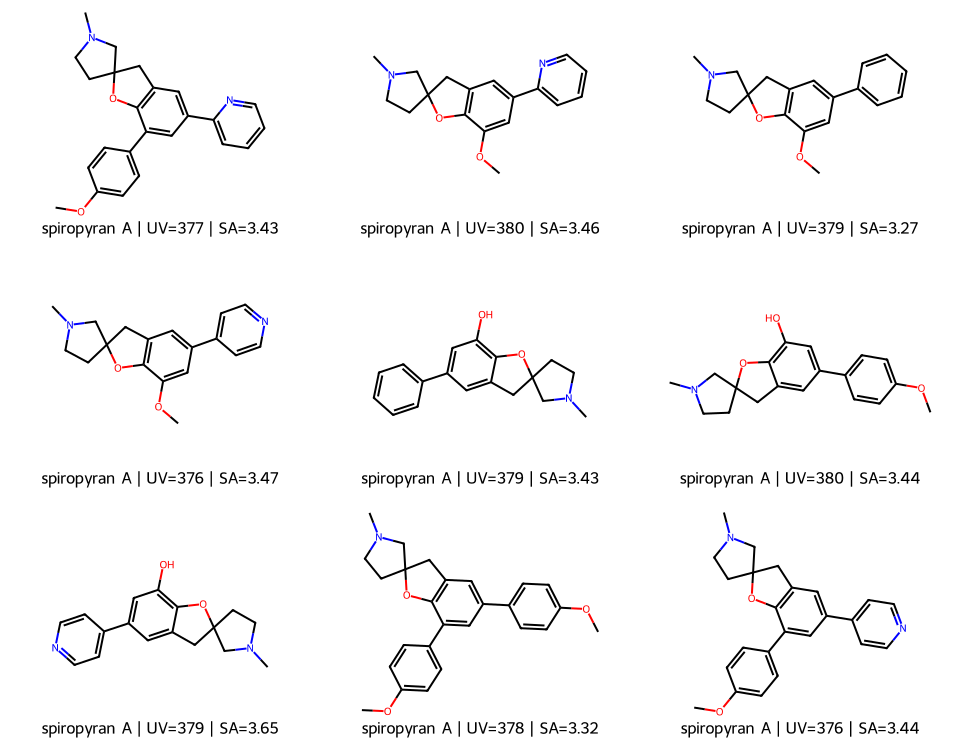

spiropyran: corresponding state B


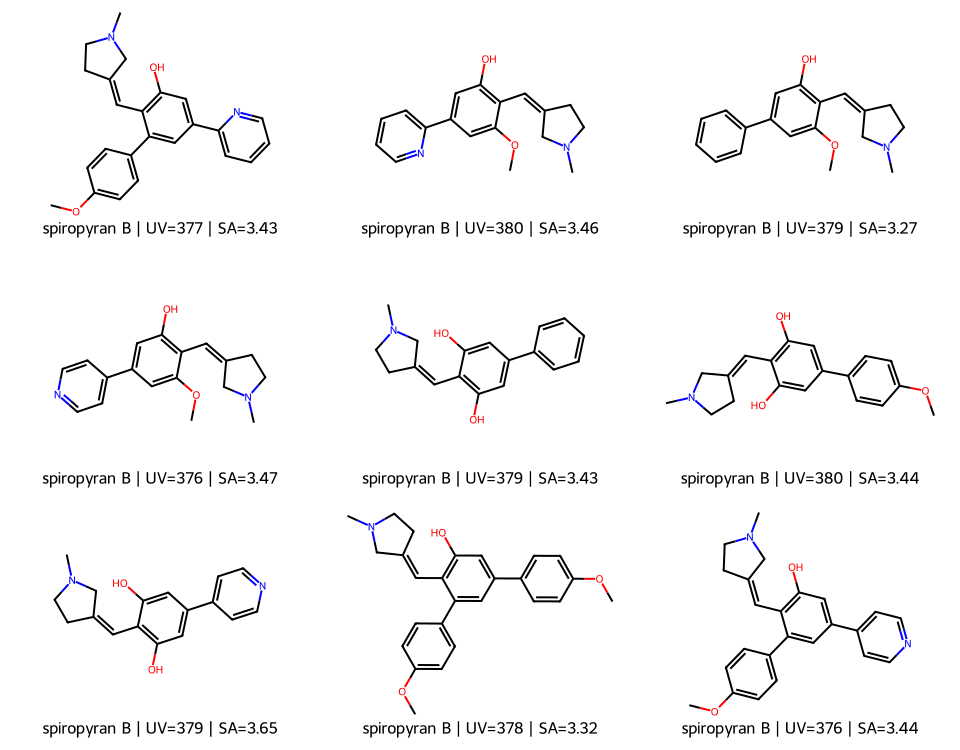

,candidate_id,rank_within_family,canonical_smiles,state_A_smiles,state_B_smiles,eval_uv_lambda_nm,sa_score,selection_score,final_status
750,MC-DIARYLETHENE-0751,1,COc1ccc(-c2ccc(-c3sc(C)c(C4=C(c5c(C)sc(-c6ccc(...,COc1ccc(-c2ccc(-c3sc(C)c(C4=C(c5c(C)sc(-c6ccc(...,COc1ccc(-c2ccc(C3=C(C)C4=C5C(=C6C(C)=C(c7ccc(C...,356.024342,3.212706,0.451221,PASS_DIARYLETHENE_AND_TOXICITY_SCREEN
751,MC-DIARYLETHENE-0752,2,COc1ccc(-c2sc(C)c(C3=C(c4c(C)sc(-c5ccc(-c6ccc(...,COc1ccc(-c2sc(C)c(C3=C(c4c(C)sc(-c5ccc(-c6ccc(...,COc1ccc(C2=C(C)C3=C4C(=C5C(C)=C(c6ccc(-c7ccc(C...,356.024342,3.212706,0.451221,PASS_DIARYLETHENE_AND_TOXICITY_SCREEN
752,MC-DIARYLETHENE-0753,3,COc1ccc(-c2sc(C)c(C3=C(c4c(C)sc(-c5ccc(-c6cccc...,COc1ccc(-c2sc(C)c(C3=C(c4c(C)sc(-c5ccc(-c6cccc...,COc1ccc(C2=C(C)C3=C4C(=C5C(C)=C(c6ccc(-c7ccccc...,357.923172,3.164397,0.450808,PASS_DIARYLETHENE_AND_TOXICITY_SCREEN
753,MC-DIARYLETHENE-0754,4,COc1ccc(-c2sc(C)c(C3=C(c4c(C)sc(-c5ccc(OC)cc5)...,COc1ccc(-c2sc(C)c(C3=C(c4c(C)sc(-c5ccc(OC)cc5)...,COc1ccc(C2=C(C)C3=C4C(=C5C(C)=C(c6ccc(OC)cc6)S...,362.042810,3.152756,0.450185,PASS_DIARYLETHENE_AND_TOXICITY_SCREEN
754,MC-DIARYLETHENE-0755,5,COc1ccc(-c2ccc(-c3sc(C)c(C4=C(c5c(C)sc(-c6ccc(...,COc1ccc(-c2ccc(-c3sc(C)c(C4=C(c5c(C)sc(-c6ccc(...,COc1ccc(-c2ccc(C3=C(C)C4=C5C(=C6C(C)=C(c7ccc(O...,363.981501,3.251873,0.449176,PASS_DIARYLETHENE_AND_TOXICITY_SCREEN
755,MC-DIARYLETHENE-0756,6,CNc1ccc(-c2sc(C)c(C3=C(c4c(C)sc(-c5ccc(-c6ccc(...,CNc1ccc(-c2sc(C)c(C3=C(c4c(C)sc(-c5ccc(-c6ccc(...,CNc1ccc(C2=C(C)C3=C4C(=C5C(C)=C(c6ccc(-c7ccc(O...,360.704080,3.305117,0.447603,PASS_DIARYLETHENE_AND_TOXICITY_SCREEN
756,MC-DIARYLETHENE-0757,7,COc1ccc(-c2sc(C)c(C3=C(c4c(C)sc(-c5ccc(-c6ccnc...,COc1ccc(-c2sc(C)c(C3=C(c4c(C)sc(-c5ccc(-c6ccnc...,COc1ccc(C2=C(C)C3=C4C(=C5C(C)=C(c6ccc(-c7ccncc...,358.794945,3.305910,0.447313,PASS_DIARYLETHENE_AND_TOXICITY_SCREEN
757,MC-DIARYLETHENE-0758,8,COc1ccc(-c2sc(C)c(C3=C(c4c(C)sc(-c5ccc(Cl)cc5)...,COc1ccc(-c2sc(C)c(C3=C(c4c(C)sc(-c5ccc(Cl)cc5)...,COc1ccc(C2=C(C)C3=C4C(=C5C(C)=C(c6ccc(Cl)cc6)S...,361.418012,3.275540,0.443159,PASS_DIARYLETHENE_AND_TOXICITY_SCREEN
758,MC-DIARYLETHENE-0759,9,COc1ccc(-c2ccc(-c3sc(C)c(C4=C(c5c(C)sc(-c6ccc(...,COc1ccc(-c2ccc(-c3sc(C)c(C4=C(c5c(C)sc(-c6ccc(...,COc1ccc(-c2ccc(C3=C(C)C4=C5C(=C6C(C)=C(c7ccc(C...,365.967087,3.325188,0.442690,PASS_DIARYLETHENE_AND_TOXICITY_SCREEN


diarylethene: state A


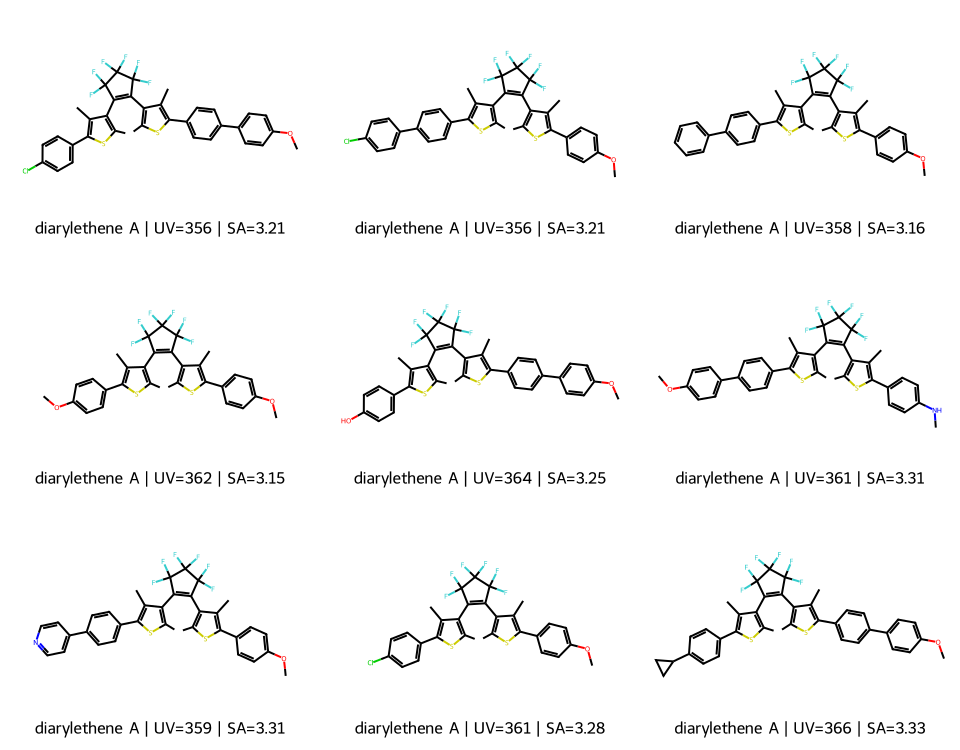

diarylethene: corresponding state B


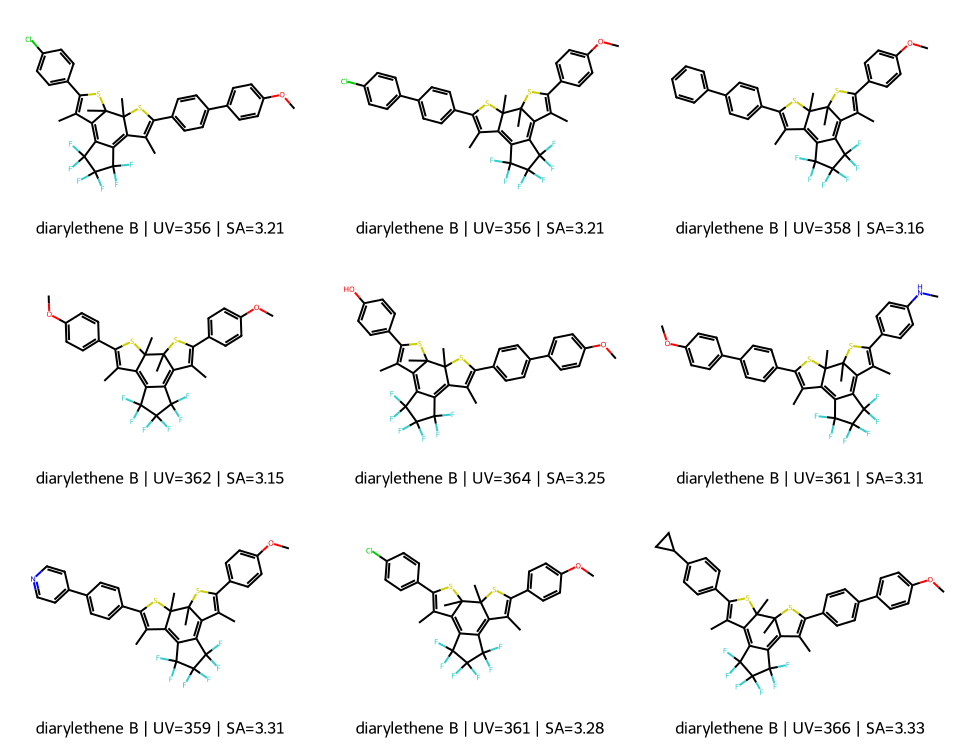

In [6]:
def show_family_pairs(family, count=9):
    top = (
        df[df["family"].eq(family)]
        .sort_values("rank_within_family")
        .drop_duplicates("canonical_smiles")
        .head(count)
    )
    display(top[[
        "candidate_id", "rank_within_family", "canonical_smiles",
        "state_A_smiles", "state_B_smiles", "eval_uv_lambda_nm", "sa_score",
        "selection_score", "final_status",
    ]])
    state_a = [Chem.MolFromSmiles(s) for s in top["state_A_smiles"]]
    state_b = [Chem.MolFromSmiles(s) for s in top["state_B_smiles"]]
    legends_a = [f"{family} A | UV={r.eval_uv_lambda_nm:.0f} | SA={r.sa_score:.2f}" for r in top.itertuples()]
    legends_b = [f"{family} B | UV={r.eval_uv_lambda_nm:.0f} | SA={r.sa_score:.2f}" for r in top.itertuples()]
    print(f"{family}: state A")
    display(Draw.MolsToGridImage(state_a, legends=legends_a, molsPerRow=3, subImgSize=(320, 250), useSVG=True))
    print(f"{family}: corresponding state B")
    display(Draw.MolsToGridImage(state_b, legends=legends_b, molsPerRow=3, subImgSize=(320, 250), useSVG=True))

show_family_pairs("azo")
show_family_pairs("stilbene")
show_family_pairs("spiropyran")
show_family_pairs("diarylethene")

### Научная граница результата

Все классы входят в общий conditional checkpoint, но connectivity-changing
spiropyran и diarylethene pairs дополнительно ограничены реакционными шаблонами.
Фототоксичность обучена на 53 структурах QDB и поэтому для новых scaffold часто
находится вне applicability domain. PSS, quantum yield, ΔH и stored energy
намеренно остаются пустыми до физической валидации.

## Метрики генерации

Отдельный финальный вывод показывает метрики как для всех proposals,
так и для отобранного top-1000. Единичные метрики top-1000 являются следствием
целевого отбора; качество самого generator следует оценивать по scope
`all_proposals`.

,metric,definition
0,Validity,Nvalid / Ngenerated
1,Uniqueness,Nunique_valid / Nvalid
2,Novelty,Nunique_valid_not_in_training / Nunique_valid
3,JSR,N(target_A_pass AND target_B_pass) / Ngenerated
4,Diversity,1 - mean pairwise Morgan/Tanimoto similarity o...


,scope,family,n_generated,n_valid,n_unique,n_not_in_training,n_joint_success,validity,uniqueness,novelty,joint_success_rate,diversity
0,all_proposals,all,21343,21343,15526,15516,8739,1.0,0.727452,0.999356,0.409455,0.852093
1,all_proposals,azo,8000,8000,6623,6622,3153,1.0,0.827875,0.999849,0.394125,0.805771
2,all_proposals,stilbene,8000,8000,5463,5459,5147,1.0,0.682875,0.999268,0.643375,0.782724
3,all_proposals,spiropyran,2976,2976,1218,1213,187,1.0,0.409274,0.995895,0.062836,0.640406
4,all_proposals,diarylethene,2367,2367,2328,2325,252,1.0,0.983523,0.998711,0.106464,0.871385
5,top_1000,all,1000,1000,1000,1000,931,1.0,1.000000,1.000000,0.931000,0.814543
6,top_1000,azo,250,250,250,250,250,1.0,1.000000,1.000000,1.000000,0.733833
7,top_1000,stilbene,250,250,250,250,250,1.0,1.000000,1.000000,1.000000,0.519069
8,top_1000,spiropyran,250,250,250,250,187,1.0,1.000000,1.000000,0.748000,0.502636
9,top_1000,diarylethene,250,250,250,250,244,1.0,1.000000,1.000000,0.976000,0.459435


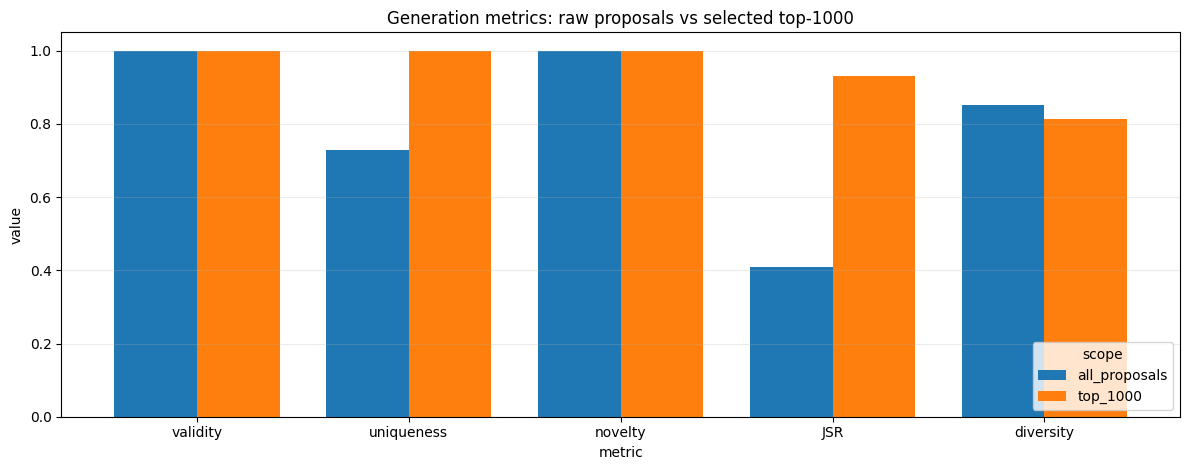

,validation,n_compounds,n_phototoxic,n_non_phototoxic,roc_auc,balanced_accuracy_at_0_5,brier_score
0,5-fold stratified out-of-fold,53,37,16,0.780405,0.677365,0.191973


,QDB_structured_training_rows,QDB_phototoxic,QDB_non_phototoxic,PhotoChem_CAS_linked_rows,PhotoChem_agreement
0,53,37,16,33,0.909091


In [7]:
metrics = pd.read_csv(METRICS_PATH)
required_metrics = {
    "scope", "family", "n_generated", "n_valid", "n_unique",
    "n_not_in_training", "n_joint_success", "validity", "uniqueness",
    "novelty", "joint_success_rate", "diversity",
}
missing_metrics = required_metrics.difference(metrics.columns)
if missing_metrics:
    raise KeyError(f"generation_metrics.csv is missing: {sorted(missing_metrics)}")

scope_order = ["all_proposals", "top_1000"]
family_order = ["all", "azo", "stilbene", "spiropyran", "diarylethene"]
metrics["scope"] = pd.Categorical(metrics["scope"], scope_order, ordered=True)
metrics["family"] = pd.Categorical(metrics["family"], family_order, ordered=True)
metrics = metrics.sort_values(["scope", "family"]).reset_index(drop=True)

formulas = pd.DataFrame({
    "metric": ["Validity", "Uniqueness", "Novelty", "JSR", "Diversity"],
    "definition": [
        "Nvalid / Ngenerated",
        "Nunique_valid / Nvalid",
        "Nunique_valid_not_in_training / Nunique_valid",
        "N(target_A_pass AND target_B_pass) / Ngenerated",
        "1 - mean pairwise Morgan/Tanimoto similarity over unique valid structures",
    ],
})
display(formulas)

metrics_display = metrics.copy()
rate_columns = ["validity", "uniqueness", "novelty", "joint_success_rate", "diversity"]
metrics_display[rate_columns] = metrics_display[rate_columns].round(6)
display(metrics_display)

overall = (
    metrics[metrics["family"].eq("all")]
    .set_index("scope")[rate_columns]
    .rename(columns={"joint_success_rate": "JSR"})
)
axes = overall.T.plot.bar(figsize=(12, 4.8), ylim=(0, 1.05), width=0.78)
axes.set(title="Generation metrics: raw proposals vs selected top-1000", xlabel="metric", ylabel="value")
axes.grid(axis="y", alpha=0.25)
axes.legend(title="scope", loc="lower right")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

toxicity_model_metrics = pd.read_csv(TOXICITY_METRICS_PATH)
toxicity_training = pd.read_csv(TOXICITY_TRAINING_PATH)
linked = toxicity_training.dropna(subset=["photochem_label"])
toxicity_evidence = pd.DataFrame([{
    "QDB_structured_training_rows": len(toxicity_training),
    "QDB_phototoxic": int(toxicity_training["phototoxic"].sum()),
    "QDB_non_phototoxic": int((toxicity_training["phototoxic"] == 0).sum()),
    "PhotoChem_CAS_linked_rows": len(linked),
    "PhotoChem_agreement": linked["photochem_agrees"].astype(str).str.lower().eq("true").mean(),
}])
display(toxicity_model_metrics.round(6))
display(toxicity_evidence.round(6))